# Classification using Random Forests - Exercise

In this exercise, we want to classify digits (0 to 9) on a dataset from sklearn.

**Digits dataset from sklearn**

In [5]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
from sklearn.datasets import load_digits

digits = load_digits()
list(digits)

['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR']

In [3]:
#%matplotlib inline
#import matplotlib.pyplot as plt

**This exercise concerns the image processing field (containing numerical information)**

This dataset and its features represent the color intensity in each pixel, in a grayscale, and ranging between **0 (black)** and **16 (white)**, for a total of **64 pixels** (``8 rows x 8 columns``). This information can be seen in the images that follow, and in the dataframe below:

<Figure size 640x480 with 0 Axes>

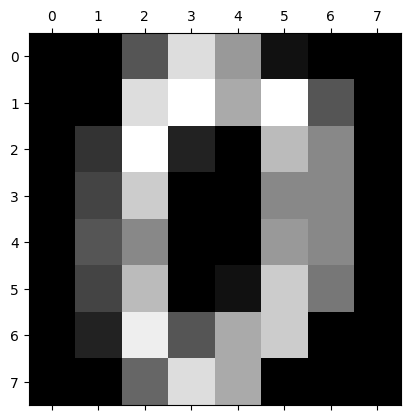

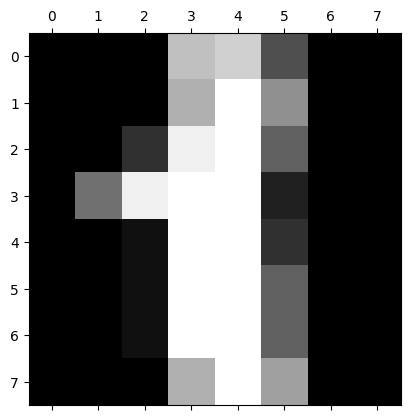

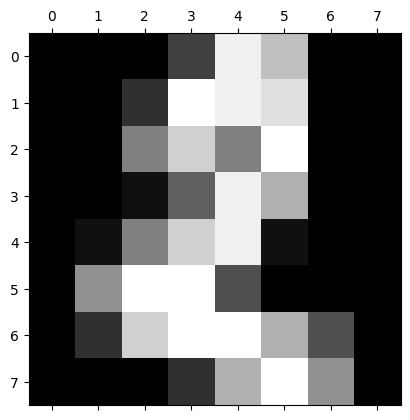

In [6]:
plt.gray()
for i in range(3):
    plt.matshow(digits.images[i]) 

In [7]:
df = pd.DataFrame(digits.data)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


**There is a target, which corresponds to the integer representation of each line and can have values between 0 and 1**.

In [17]:
df['target'] = digits.target
df.tail()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9
1796,0.0,0.0,10.0,14.0,8.0,1.0,0.0,0.0,0.0,2.0,...,0.0,0.0,1.0,8.0,12.0,14.0,12.0,1.0,0.0,8


**1. Prepare the dataset**

HINT: ``X`` and ``y`` subsets

In [18]:
X = df.iloc[:, 0:64].values
y = df.iloc[:, 64].values

array([0, 1, 2, ..., 8, 9, 8])

**2. Perform the train-test split (80/20)**

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

**3. Fit a Random Forest Classifier with ``100`` trees** 

HINT: Use the ``n_estimators`` parameter of the ``RandomForestClassifier`` .

In [39]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100, random_state=0)
classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

**4. Make the necessary prediction**

In [40]:
y_pred = classifier.predict(X_test)

**5. Evaluate our model in terms of mean accuracy**

HINT: Use the ``score`` method directly from the generated model.

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8])
confusion = pd.DataFrame(cm, index=['authentic-0', 'authentic-1', 'authentic-2', 'authentic-3', 'authentic-4', 'authentic-5', 'authentic-6', 'authentic-7', 'authentic-8'],
                         columns=['predicted-0','predicted-1','predicted-2','predicted-3','predicted-4','predicted-5','predicted-6','predicted-7','predicted-8'])
confusion

,predicted-0,predicted-1,predicted-2,predicted-3,predicted-4,predicted-5,predicted-6,predicted-7,predicted-8
authentic-0,27,0,0,0,0,0,0,0,0
authentic-1,0,34,0,0,0,1,0,0,0
authentic-2,1,1,34,0,0,0,0,0,0
authentic-3,0,0,0,29,0,0,0,0,0
authentic-4,0,0,0,0,29,0,0,1,0
authentic-5,0,0,0,0,0,38,0,0,0
authentic-6,0,0,0,0,0,0,44,0,0
authentic-7,0,0,0,0,0,0,0,39,0
authentic-8,0,1,0,0,0,0,0,0,38


**5. Create a confusion matrix**

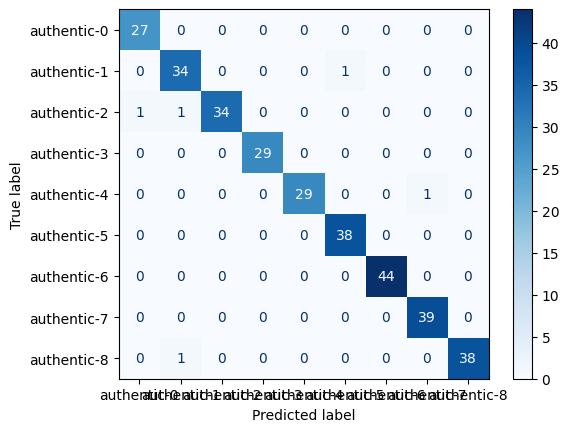

In [42]:
cm_fig = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['authentic-0', 'authentic-1', 'authentic-2', 'authentic-3', 'authentic-4', 'authentic-5', 'authentic-6', 'authentic-7', 'authentic-8'])
cm_fig.plot(cmap='Blues')

**6. Print a classification report and a more precise accuracy score**

HINT: Use ``accuracy_score`` method from ``sklearn.metrics``

In [43]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       0.94      0.97      0.96        35
           2       1.00      0.94      0.97        36
           3       0.94      1.00      0.97        29
           4       1.00      0.97      0.98        30
           5       0.93      0.95      0.94        40
           6       1.00      1.00      1.00        44
           7       0.97      1.00      0.99        39
           8       1.00      0.97      0.99        39
           9       0.95      0.90      0.92        41

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

0.9694444444444444


**7. Can we improve? How?**

If we increase the number of trees to 1000, the accuracy is 0.975, a slight improvement. 